# Experiment 10:  Implement the Deep Reinforcement Learning for Agent Environment Interaction

# Name: Nabeel Shan - BESE-29C

In [3]:
# Import Tensorflow 2.0
%tensorflow_version 2.x
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Download and import the MIT 6.S191 package
!printf "Installing MIT deep learning package... "
!pip install --upgrade git+https://github.com/MITDeepLearning/introtodeeplearning.git &> /dev/null
!echo "Done"

# Install dependencies for visualizing the agents
!apt-get install -y xvfb python-opengl x11-utils &> /dev/null
!pip install gym pyvirtualdisplay scikit-video ffio pyrender &> /dev/null

# --- FIX IS HERE ---
# Upgrading to the latest tensorflow_probability instead of forcing the broken 0.12.0 version
!pip install --upgrade tensorflow_probability &> /dev/null

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Installing MIT deep learning package... Done


In [4]:
import os
os.environ['PYOPENGL_PLATFORM'] = 'egl'

import numpy as np
import matplotlib, cv2
import matplotlib.pyplot as plt
import base64, io, time, gym
import IPython, functools
from tqdm import tqdm
import tensorflow_probability as tfp
import mitdeeplearning as mdl

# Patch for NumPy 2.0 compatibility with older Gym versions
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

/usr/local/lib/python3.12/dist-packages/tensorflow_probability/python/__init__.py:57: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  #
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
### Instantiate the Cartpole environment ###
env = gym.make("CartPole-v1")
env.seed(1)

n_observations = env.observation_space.shape[0]
print("Environment has observation space dimensionality =", n_observations)

n_actions = env.action_space.n
print("Number of possible actions that the agent can choose from =", n_actions)

Environment has observation space dimensionality = 4
Number of possible actions that the agent can choose from = 2


/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


In [6]:
### Define the Cartpole agent ###

# Defines a feed-forward neural network
def create_cartpole_model():
    model = tf.keras.models.Sequential([
        # First Dense layer
        tf.keras.layers.Dense(units=32, activation='relu'),

        # Output layer: Maps the 32 hidden units to the 'n_actions' (Left, Right)
        # We use activation=None because we want raw logits, not softmax probabilities yet.
        # The cross-entropy function later will handle the softmax internally for numerical stability.
        tf.keras.layers.Dense(units=n_actions, activation=None)
    ])
    return model

cartpole_model = create_cartpole_model()

In [7]:
### Define the agent's action function ###

def choose_action(model, observation, single=True):
    # add batch dimension to the observation if only a single example was provided
    observation = np.expand_dims(observation, axis=0) if single else observation

    # Feed the observations through the model to predict the log probabilities (logits)
    logits = model(observation)

    # Choose an action from the categorical distribution defined by the logits.
    # tf.random.categorical expects logits and outputs indices.
    action = tf.random.categorical(logits, num_samples=1)

    action = action.numpy().flatten()
    return action[0] if single else action

In [8]:
### Agent Memory ###

class Memory:
    def __init__(self):
        self.clear()

    # Resets/restarts the memory buffer
    def clear(self):
        self.observations = []
        self.actions = []
        self.rewards = []

    # Add observations, actions, rewards to memory
    def add_to_memory(self, new_observation, new_action, new_reward):
        self.observations.append(new_observation)

        # Update the list of actions with new action
        self.actions.append(new_action)

        # Update the list of rewards with new reward
        self.rewards.append(new_reward)

    def __len__(self):
        return len(self.actions)

# Instantiate a single Memory buffer
memory = Memory()

In [9]:
### Reward function ###

# Helper function that normalizes an np.array x
def normalize(x):
    x -= np.mean(x)
    x /= (np.std(x) + 1e-8) # Add tiny epsilon to prevent division by zero
    return x.astype(np.float32)

# Compute normalized, discounted, cumulative rewards (i.e., return)
def discount_rewards(rewards, gamma=0.95):
    discounted_rewards = np.zeros_like(rewards, dtype=np.float32)
    R = 0
    for t in reversed(range(0, len(rewards))):
        # update the total discounted reward
        R = R * gamma + rewards[t]
        discounted_rewards[t] = R

    return normalize(discounted_rewards)

In [10]:
### Loss function ###

def compute_loss(logits, actions, rewards):
    # Compute the negative log probabilities
    neg_logprob = tf.nn.sparse_softmax_cross_entropy_with_logits(
        logits=logits, labels=actions)

    # Scale the negative log probability by the rewards
    # Good actions (positive reward) will be pushed to be more likely
    # Bad actions (negative/lower reward) will be pushed to be less likely
    loss = tf.reduce_mean(neg_logprob * rewards)
    return loss

### Training step (forward and backpropagation) ###

def train_step(model, loss_function, optimizer, observations, actions, discounted_rewards, custom_fwd_fn=None):
    with tf.GradientTape() as tape:
        # Forward propagate through the agent network
        if custom_fwd_fn is not None:
            prediction = custom_fwd_fn(observations)
        else:
            prediction = model(observations)

        # Call the compute_loss function to compute the loss
        loss = loss_function(prediction, actions, discounted_rewards)

    # Run backpropagation to minimize the loss
    grads = tape.gradient(loss, model.trainable_variables)

    # Clip gradients to avoid exploding gradients
    grads, _ = tf.clip_by_global_norm(grads, 2.0)

    optimizer.apply_gradients(zip(grads, model.trainable_variables))

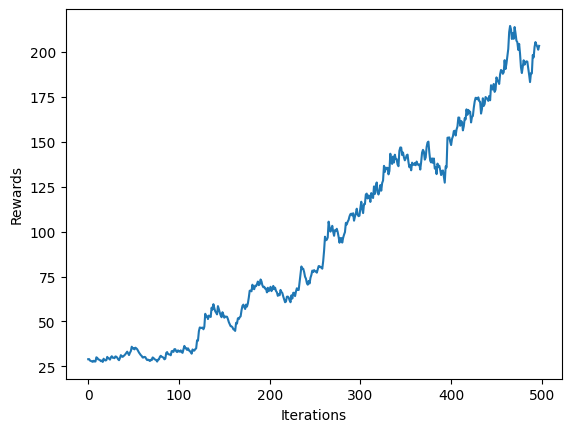

Training completed! Maximum reward achieved: 467.0


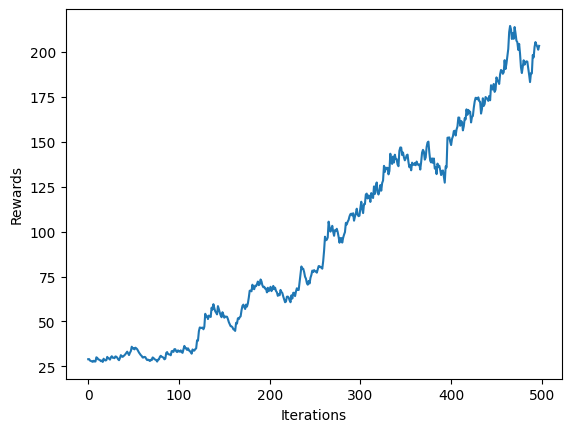

In [11]:
## Training parameters ##
# Use Adam optimizer with a standard learning rate for RL
learning_rate = 1e-3
optimizer = tf.keras.optimizers.Adam(learning_rate)

# instantiate cartpole agent
cartpole_model = create_cartpole_model()

# to track our progress
smoothed_reward = mdl.util.LossHistory(smoothing_factor=0.95)
plotter = mdl.util.PeriodicPlotter(sec=2, xlabel='Iterations', ylabel='Rewards')

# Store history for advanced plotting later
raw_rewards_history = []

if hasattr(tqdm, '_instances'): tqdm._instances.clear() # clear if it exists

print("Starting Deep RL Training Loop...")
for i_episode in range(500):

    plotter.plot(smoothed_reward.get())

    # Restart the environment
    res = env.reset()
    observation = res[0] if isinstance(res, tuple) else res
    memory.clear()

    while True:
        # using our observation, choose an action and take it in the environment
        action = choose_action(cartpole_model, observation)

        step_res = env.step(action)
        if len(step_res) == 5:
            next_observation, reward, terminated, truncated, info = step_res
            done = terminated or truncated
        else:
            next_observation, reward, done, info = step_res

        # add to memory
        memory.add_to_memory(observation, action, reward)

        if done:
            # determine total reward and keep a record of this
            total_reward = sum(memory.rewards)
            smoothed_reward.append(total_reward)
            raw_rewards_history.append(total_reward)

            # initiate training
            train_step(cartpole_model, compute_loss, optimizer,
                       observations=np.vstack(memory.observations),
                       actions=np.array(memory.actions),
                       discounted_rewards=discount_rewards(memory.rewards))

            memory.clear()
            break

        # update our observatons
        observation = next_observation

print(f"Training completed! Maximum reward achieved: {max(raw_rewards_history)}")

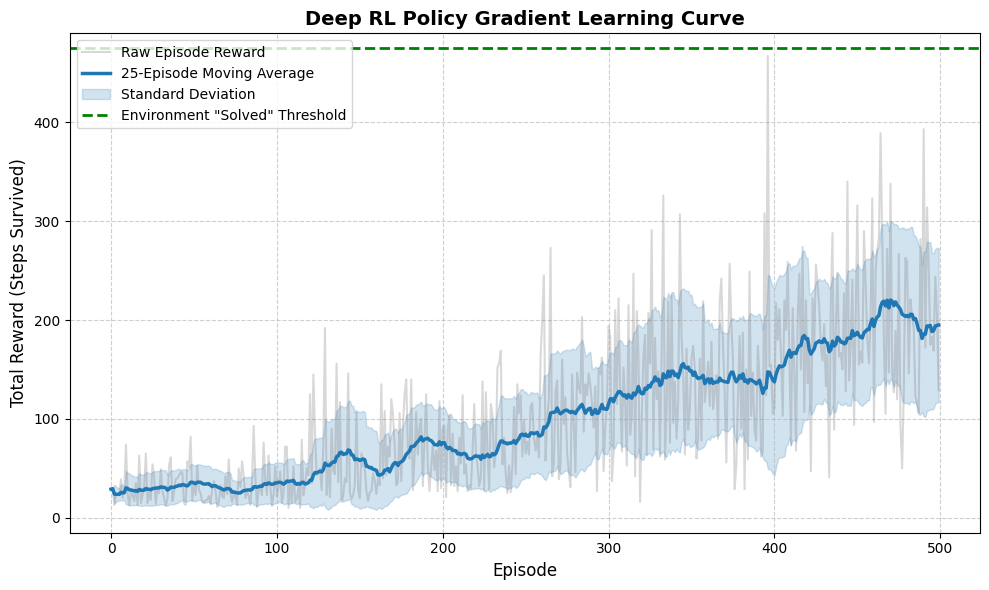

In [12]:
# --- ADVANCED VISUALIZATION ---
import pandas as pd

def plot_learning_curve(rewards, window=25):
    """Plots a smoothed learning curve with variance bands."""
    rewards_series = pd.Series(rewards)

    # Calculate rolling mean and standard deviation
    rolling_mean = rewards_series.rolling(window=window, min_periods=1).mean()
    rolling_std = rewards_series.rolling(window=window, min_periods=1).std()

    plt.figure(figsize=(10, 6), dpi=100)

    # Plot the raw rewards as faint background noise
    plt.plot(rewards, color='gray', alpha=0.3, label='Raw Episode Reward')

    # Plot the smoothed trendline
    plt.plot(rolling_mean, color='#1f77b4', linewidth=2.5, label=f'{window}-Episode Moving Average')

    # Fill the variance area
    plt.fill_between(range(len(rewards)),
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     color='#1f77b4', alpha=0.2, label='Standard Deviation')

    plt.title('Deep RL Policy Gradient Learning Curve', fontsize=14, fontweight='bold')
    plt.xlabel('Episode', fontsize=12)
    plt.ylabel('Total Reward (Steps Survived)', fontsize=12)
    plt.axhline(y=475, color='green', linestyle='--', linewidth=2, label='Environment "Solved" Threshold')

    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_learning_curve(raw_rewards_history)